# 02 · Crop action-feature research

**Status: first bounded experiment; feature research remains open.**

We test crop lifecycle value, watering urgency, labor allocation and terminal banking in one fixed deterministic scheduler. Each comparison removes one family’s contribution. The result is conditional on this policy and its fixed weights, not a universal ranking of features.

[Experiment specification](../docs/feature_experiment.md) · [Official mechanics](https://github.com/Kaggle/kaggle-environments/tree/master/kaggle_environments/envs/kaggriculture) · [Companion discussion](https://www.kaggle.com/competitions/kaggriculture/discussion/740550)

The scope is 80 full games: five variants, two deterministic opponents, four development seeds and both seats. No validation or holdout seeds, fitted coefficients, final model selection or competition submission.

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from kaggriculture_research.artifacts import digest, file_digest
from kaggriculture_research.crop_policy import crop_scenario
from kaggriculture_research.environment import game
from kaggriculture_research.visuals import show_figure

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
report = json.loads((root / "reports/feature_research.json").read_text())
protocol = json.loads((root / "configs/feature_research.json").read_text())
assert digest(protocol) == report["protocol_sha256"]
for name, sha in report["lineage"]["code"].items():
    assert file_digest(root / "src/kaggriculture_research" / name) == sha, name
assert report["games"] == 80 and not report["validation_or_holdout_used"]
assert report["feature_completion_gate"] == "closed"
print(
    "Verified:", report["games"], "full games; four development seed clusters; feature gate closed."
)

Verified: 80 full games; four development seed clusters; feature gate closed.


## Mechanism before measurement

A crop’s advertised maximum yield is not its guaranteed yield. We simulate daily irrigation without fertilizer and compare the formula with the official interpreter in tests. The conditional value uses current market prices and seed cost. It assumes one harvest and two delivery actions; it does not predict future prices, actual route feasibility or the opponent’s sales. The scheduler separately checks end-of-season delivery distance.

For non-repeating crops, watering on the harvest day can add yield. A newly planted crop begins with one unwatered day. The final partial day has no automatic deposit before scoring: carried produce must reach the shed and be sold.

In [2]:
scenario_rows = []
for crop in sorted(game.CROPS):
    scenario = crop_scenario(crop, 10000, 719, 0)
    scenario_rows.append(
        {
            "crop": crop,
            "advertised_cap": game.CROPS[crop]["max_yield"],
            "irrigated_units": scenario.units,
            "harvest_age_days": scenario.harvest_age,
            "work_actions": scenario.work_actions,
            "conditional_net_coins": scenario.net_coins,
            "net_coins_per_work_action": round(scenario.net_coins / scenario.work_actions, 2),
        }
    )
scenarios = pd.DataFrame(scenario_rows)
display(scenarios)

,crop,advertised_cap,irrigated_units,harvest_age_days,work_actions,conditional_net_coins,net_coins_per_work_action
0,CARROT,4,3,3,8,82.0,10.25
1,MELON,6,6,12,17,1420.0,83.53
2,STRAWBERRY,4,4,16,21,368.0,17.52
3,TOMATO,4,4,11,16,179.0,11.19
4,WHEAT,6,4,4,9,87.0,9.67


## Feature ledger and intervention

These are 13 action-feature templates instantiated per crop, tile or task. They are separate from notebook 01’s 244 state descriptors. They have been screened through mechanics, information-availability checks and grouped ablations; none is finally retained or rejected yet. An unhelpful result under one scheduler is insufficient evidence to discard a family.

| Family | Fixed intervention when removed | Availability |
|---|---|---|
| Crop value | Equal planting scores instead of conditional net value per work action | Public crop mechanics, current market and own seeds |
| Water urgency | Fixed watering priority instead of mortality, bonus and refresh-slack terms | Public crop state and current clock |
| Labor | Remove distance weighting and workload-based hiring | Own positions, public tasks, clock and hire cost |
| Terminal | Remove maturity/banking limits and final-day carry priority | Remaining official decisions, own inventory and delivery distance |

All variants retain the same action generator, legal-action filter, reservation logic, deterministic tie-breaking and immediate shed-sales rule. No hidden replay fields enter the policy.

In [3]:
display(
    pd.DataFrame(
        [
            {
                "family": family,
                "templates": len(names),
                "features": ", ".join(names),
                "status": "provisional; family ablation evaluated",
            }
            for family, names in report["feature_templates"].items()
        ]
    )
)
print(
    {
        k: report[k]
        for k in (
            "generated_templates",
            "screened_templates",
            "retained_templates",
            "rejected_templates",
            "provisional_templates",
        )
    }
)

,family,templates,features,status
0,crop_value,3,"conditional_units, conditional_net_coins, net_...",provisional; family ablation evaluated
1,labor,4,"travel_actions, workload_actions, worker_capac...",provisional; family ablation evaluated
2,terminal,3,"decision_slack, can_bank_crop, last_day_carry_...",provisional; family ablation evaluated
3,water_urgency,3,"dies_next_refresh, water_bonus_units, refresh_...",provisional; family ablation evaluated


{'generated_templates': 13, 'screened_templates': 13, 'retained_templates': 0, 'rejected_templates': 0, 'provisional_templates': 13}


## Outcomes across the two development opponents

The official starter is a narrow reference. The carrot scheduler waters, harvests, clears weeds and sells using the same framework restricted to carrots and one farmer. These give different market activity, but neither represents leaderboard-strength opposition. A saturated local win rate makes cash diagnostics informative without turning them into the official metric.

,games,ineffective_farm_actions,match_score,mean_coin_margin,mean_coins,mean_unsold_units,opponent,variant
0,8,0,1.000,26839.375,35287.500,0.000,carrot_scheduler,full
1,8,0,1.000,30201.125,33881.750,0.000,starter,full
2,8,0,1.000,4187.000,8874.000,0.000,carrot_scheduler,no_crop_value
3,8,0,1.000,9989.625,13379.875,0.000,starter,no_crop_value
4,8,0,0.625,380.625,6778.875,0.000,carrot_scheduler,no_labor
5,8,0,0.875,3763.000,7392.125,0.000,starter,no_labor
6,8,0,1.000,22014.125,30524.500,1.875,carrot_scheduler,no_terminal
7,8,0,1.000,25112.125,28792.750,0.000,starter,no_terminal
8,8,0,1.000,26782.500,34652.500,0.000,carrot_scheduler,no_water_urgency
9,8,0,1.000,29351.750,33032.375,0.000,starter,no_water_urgency


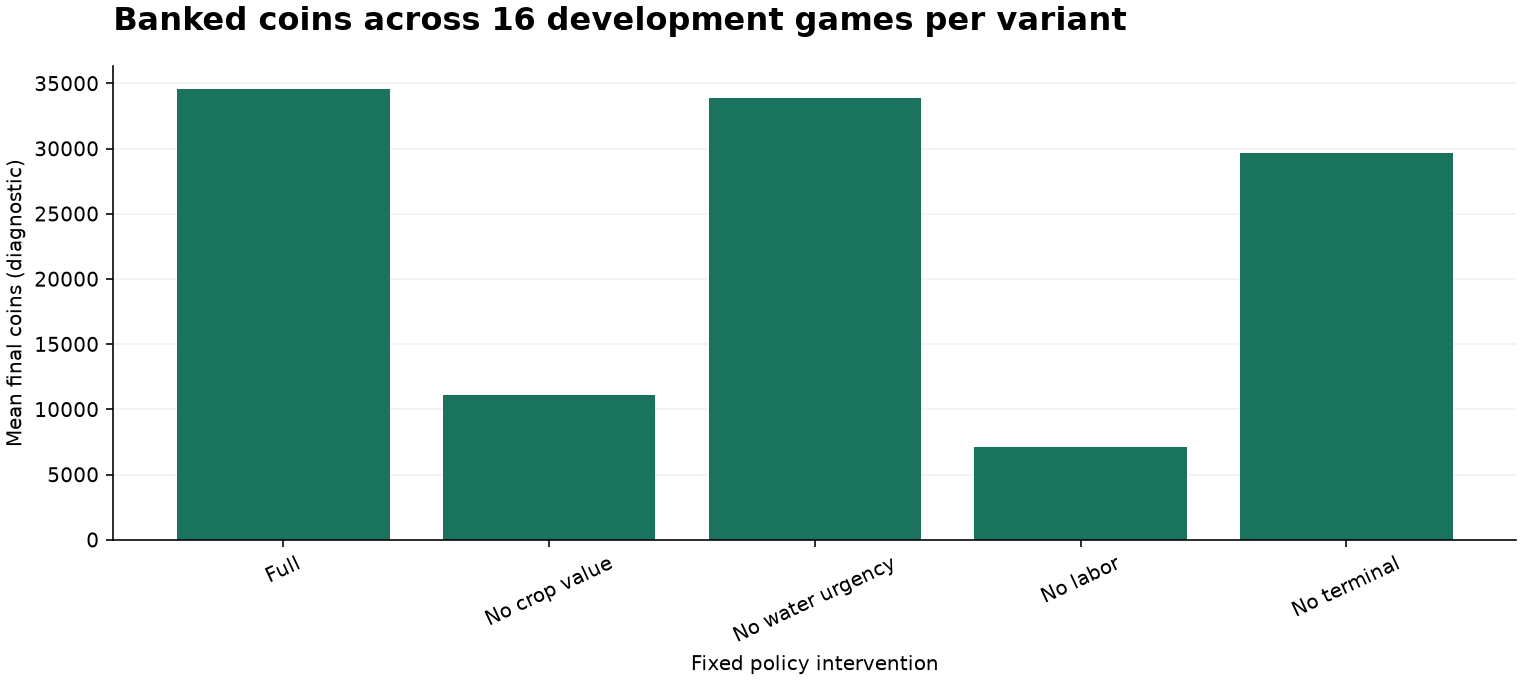

In [4]:
games = pd.read_csv(root / "reports/feature_games.csv")
pairs = pd.read_csv(root / "reports/feature_ablations.csv")
display(pd.DataFrame(report["group_results"]).round(3))
labels = {
    "full": "Full",
    "no_crop_value": "No crop value",
    "no_water_urgency": "No water urgency",
    "no_labor": "No labor",
    "no_terminal": "No terminal",
}
order = list(labels)
means = games.groupby("variant").coins.mean().reindex(order)
fig = go.Figure(go.Bar(x=[labels[v] for v in order], y=means.to_list()))
fig.update_layout(
    title="Banked coins across 16 development games per variant",
    xaxis_title="Fixed policy intervention",
    yaxis_title="Mean final coins (diagnostic)",
)
show_figure(fig)

## Paired family effects and uncertainty

We subtract each ablated policy’s outcome from the full policy for the same seed, seat and opponent, then average within seed. Bootstrap resampling operates on **four whole seed clusters**, preserving both seats and both opponents. The 95% percentile intervals are descriptive; this small exploratory batch supports no strong significance claim or multiple-comparison conclusion.

Positive coin or match-score differences favor the full policy. Negative unsold-inventory differences favor the full policy. Equal initial seeds do not force identical future towns: farm changes can alter consumption of the environment’s shared random stream.

,ablation,metric,full_minus_ablated,bootstrap_low,bootstrap_high,seed_clusters
0,no_crop_value,match_score,0.000,0.000,0.000,4
1,no_crop_value,coin_margin,21431.938,19746.812,22692.125,4
2,no_crop_value,coins,23457.688,20968.938,26012.000,4
3,no_crop_value,unsold_product_units,0.000,0.000,0.000,4
4,no_water_urgency,match_score,0.000,0.000,0.000,4
5,no_water_urgency,coin_margin,453.125,-791.938,1788.812,4
6,no_water_urgency,coins,742.188,-789.125,2653.188,4
7,no_water_urgency,unsold_product_units,0.000,0.000,0.000,4
8,no_labor,match_score,0.250,0.000,0.562,4
9,no_labor,coin_margin,26448.438,24238.250,29296.562,4


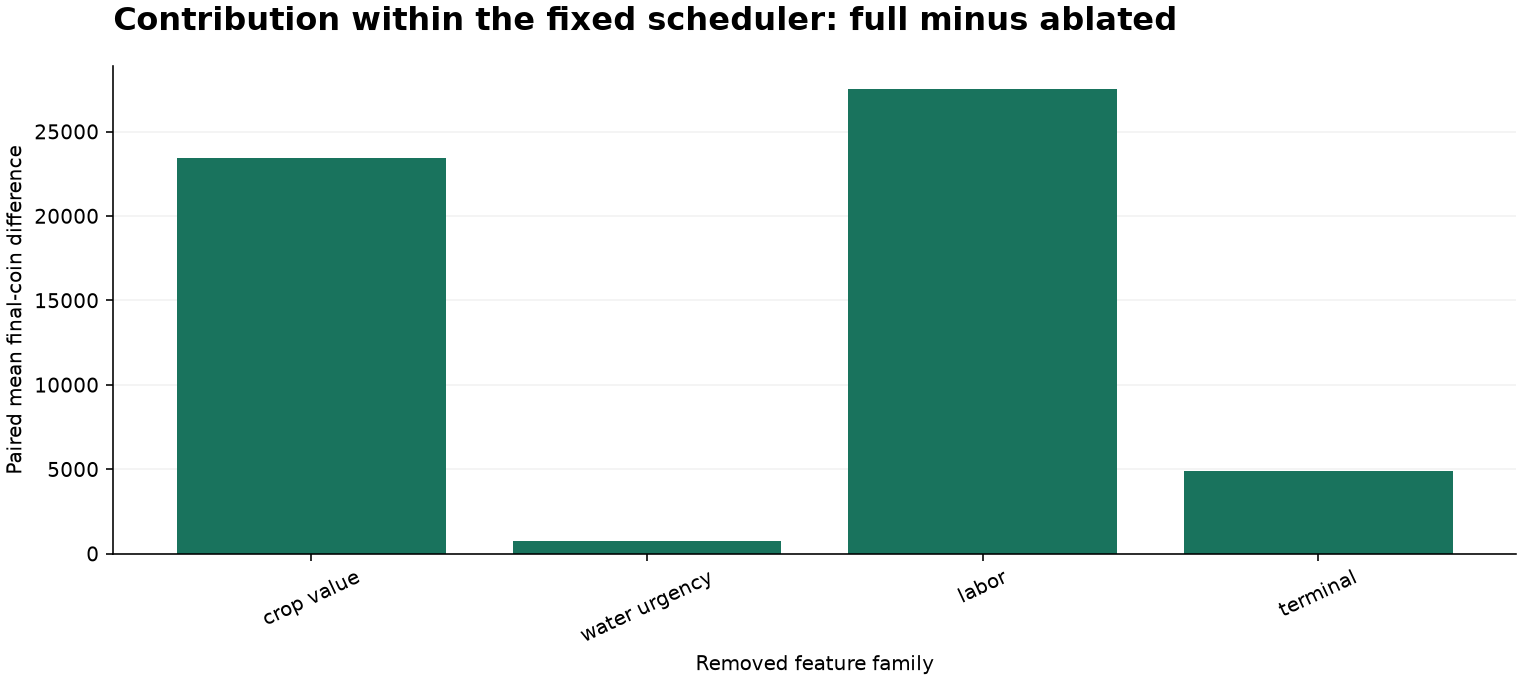

In [5]:
display(
    pairs[
        [
            "ablation",
            "metric",
            "full_minus_ablated",
            "bootstrap_low",
            "bootstrap_high",
            "seed_clusters",
        ]
    ].round(3)
)
effects = pairs[pairs.metric == "coins"]
fig = go.Figure(
    go.Bar(
        x=[labels[v].removeprefix("No ") for v in effects.ablation],
        y=effects.full_minus_ablated.to_list(),
    )
)
fig.update_layout(
    title="Contribution within the fixed scheduler: full minus ablated",
    xaxis_title="Removed feature family",
    yaxis_title="Paired mean final-coin difference",
)
show_figure(fig)

## Study the behavior, not just the score

Planting mix helps distinguish crop-choice effects from labor throughput. Harvest, water and inventory diagnostics expose failed schedules. The ineffective-action counter applies the official own-farm action function to a copy of legal observations; it measures farm actions with no effect, not market-order failures. Latency is measured in local Python callbacks and is not a competition-sandbox performance guarantee.

In [6]:
behavior = [
    "plants",
    "harvests",
    "waters",
    "passes",
    "unsold_product_units",
    "ineffective_farm_actions",
]
display(games.groupby("variant")[behavior].mean().reindex(order).round(2))
crop_columns = ["plant_" + crop for crop in sorted(game.CROPS)]
display(games.groupby("variant")[crop_columns].sum().reindex(order))
display(pd.DataFrame(report["latency_ms"]).T.round(3).rename_axis("variant"))
assert games.ineffective_farm_actions.sum() == 0
print("Silent ineffective farm actions:", int(games.ineffective_farm_actions.sum()))

,plants,harvests,waters,passes,unsold_product_units,ineffective_farm_actions
variant,,,,,,
full,74.81,66.06,688.12,108.56,0.00,0.0
no_crop_value,155.06,141.38,601.75,29.69,0.00,0.0
no_water_urgency,81.12,61.88,647.38,67.88,0.00,0.0
no_labor,26.69,4.69,183.12,15.75,0.00,0.0
no_terminal,76.56,50.44,726.81,114.81,0.94,0.0


,plant_CARROT,plant_MELON,plant_STRAWBERRY,plant_TOMATO,plant_WHEAT
variant,,,,,
full,224,800,0,0,173
no_crop_value,2475,0,0,0,6
no_water_urgency,198,880,64,0,156
no_labor,7,409,0,0,11
no_terminal,51,992,182,0,0


,max,median,p95
variant,,,
full,165.179,2.149,2.606
no_crop_value,137.979,1.956,2.485
no_labor,89.868,0.970,1.103
no_terminal,141.621,2.167,2.720
no_water_urgency,150.011,2.097,2.565


Silent ineffective farm actions: 0


## Evidence ledger and next boundary

Every raw episode is stored privately with its exact legal callback observations, actions, feature diagnostics, source lineage and semantic checksum. Public summaries are small enough to review. The following check validates all saved episode files without launching another experiment.

In [7]:
import sys

sys.path.insert(0, str(root / "scripts"))
from notebook_provenance import verify_private_artifacts

receipt1 = json.loads((root / "reports/cloud_verification.json").read_text())
evidence1 = verify_private_artifacts(root, report["artifact_manifest"], receipt1)
print("Private episode files SHA-verified in this kernel:", evidence1["local_bytes_verified"])
print("Episode hashes matched to prior download audit:", evidence1["receipt_only_verified"])
if evidence1["receipt_only_verified"]:
    print("Receipt-only private bytes were NOT reread in this kernel.")
for limitation in report["limitations"]:
    print("•", limitation)

Private episode files SHA-verified in this kernel: 0
Episode hashes matched to prior download audit: 80
Receipt-only private bytes were NOT reread in this kernel.
• Four development seed clusters only
• Two limited deterministic opponents
• Policy-component effects depend on the fixed scheduler and weights
• Current-price irrigated scenarios are not future market forecasts
• Shared environmental RNG may diverge when policies change farm state
• No final model selection, competitive claim, or leaderboard submission


**Research decision:** keep all four families provisional. This experiment establishes a measurable first layer; it does not close feature engineering. Next investigate market pressure and visible town demand, storage constraints, fertilizer and livestock economics, longer planning horizons and stronger development opponents. Validation follows only after the broader feature specification is frozen. The completion gate remains closed.

## Study 2 · Resource relationships and factorial interventions

The first experiment lost 26 harvested units per full-policy game. This study asks
whether crop value becomes useful only when maturity, shared storage, delivery and
working capital are coordinated. The frozen previous full scheduler is now the opponent.

This is **development feature research, not final model selection**. Four reused seed
clusters, both seats and every 2×2×2 combination are evaluated. `C` = capacity-aware delivery,
`K` = labor-cash reserve and `M` = local collection of capped mature crops. All-off `000`
returns the previous full scheduler exactly. Earlier smoke checks used the registered
design and did not drive parameter tuning. The same initial seed need not produce the
same future shops after different policies consume the shared RNG differently.

See [the fixed design and domain rationale](../docs/relationship_research.md) and
[the completion ledger](../docs/feature_coverage.md).

In [8]:
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from kaggriculture_research.visuals import show_figure

root = Path.cwd() if (Path.cwd() / "reports").exists() else Path.cwd().parent
relationships = json.loads((root / "reports/relationship_research.json").read_text())
games2 = pd.read_csv(root / "reports/relationship_games.csv", dtype={"arm": str})
effects2 = pd.read_csv(root / "reports/relationship_effects.csv")
registry2 = pd.read_csv(root / "reports/relationship_registry.csv")
assert relationships["games"] == len(games2) == 64
assert not relationships["validation_or_holdout_used"]
assert relationships["feature_completion_gate"] == "closed"
display(
    pd.Series(
        {
            "Full games": len(games2),
            "Independent development seed clusters": games2.seed.nunique(),
            "State/history candidates screened": len(registry2),
            "Sampled legal observations": relationships["screening"][
                "sampled_development_observations"
            ],
            "Selected final-model features": 0,
            "Exact conservation checks": relationships["conservation_verified_games"],
        },
        name="Verified scope",
    ).to_frame()
)

,Verified scope
Full games,64
Independent development seed clusters,4
State/history candidates screened,618
Sampled legal observations,11584
Selected final-model features,0
Exact conservation checks,64


### Performance against the stronger frozen opponent

Match score (win + half a tie) is the primary local comparison. Coins diagnose how a
decision changes economic output; they are not a leaderboard rating. Each row is eight
games, not eight independent samples. Both seats remain in the same seed cluster.
Arm digits are ordered **capacity / capital / maturity**. No final policy is promoted.

,games,match_score,mean_coins,mean_coin_margin,mean_discarded_units,mean_minimum_cash
arm,,,,,,
000,8,0.500,22276.00,0.000,26.0,10.0
001,8,1.000,38992.25,22576.375,0.0,14.0
010,8,0.500,22276.00,0.000,26.0,10.0
011,8,1.000,38992.25,22576.375,0.0,14.0
100,8,0.125,22358.75,-1210.500,0.0,893.0
101,8,1.000,41918.75,25016.375,0.0,976.0
110,8,0.125,22358.75,-1210.500,0.0,893.0
111,8,1.000,41918.75,25016.375,0.0,976.0


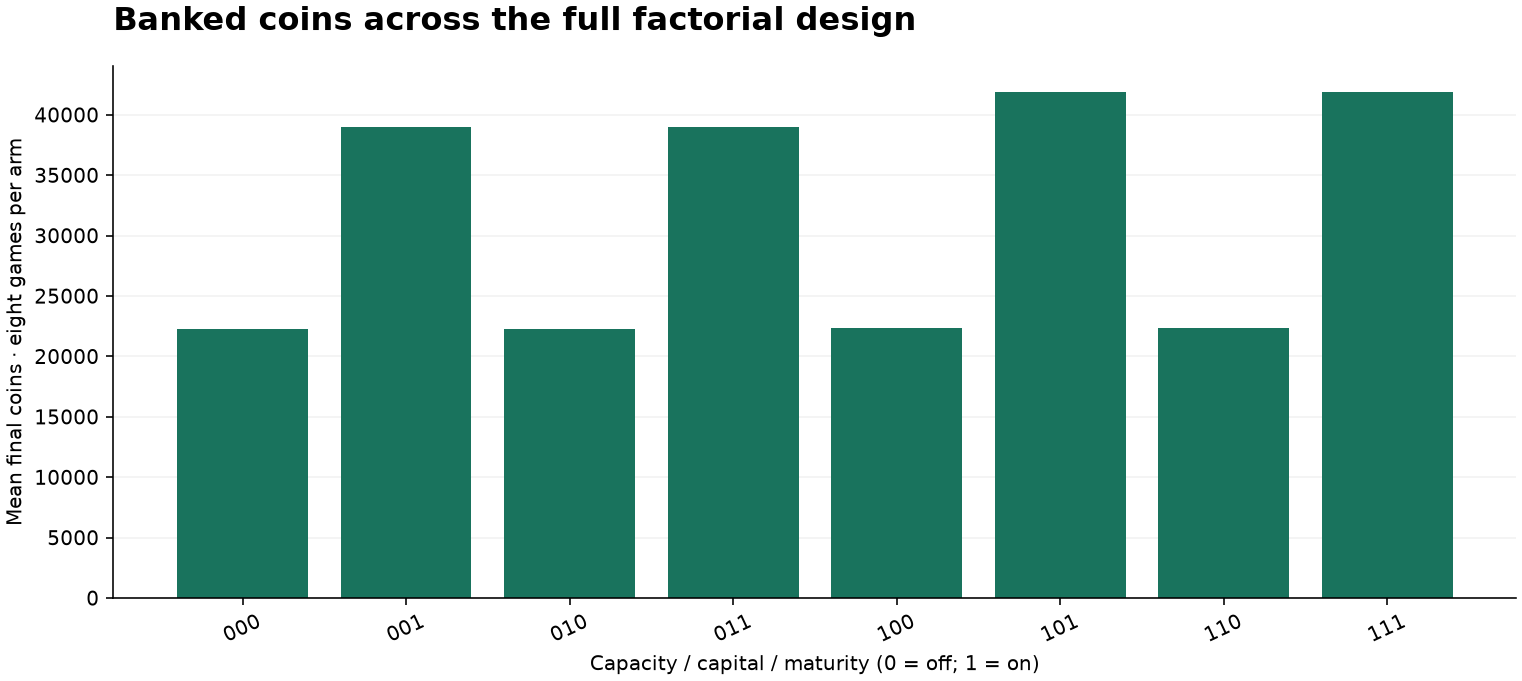

In [9]:
groups2 = games2.groupby("arm").agg(
    games=("match_score", "size"),
    match_score=("match_score", "mean"),
    mean_coins=("coins", "mean"),
    mean_coin_margin=("coin_margin", "mean"),
    mean_discarded_units=("discarded_units", "mean"),
    mean_minimum_cash=("minimum_observed_cash", "mean"),
)
display(groups2.round(3))
fig = go.Figure(go.Bar(x=groups2.index, y=groups2.mean_coins, name="Banked coins"))
fig.update_layout(
    title="Banked coins across the full factorial design",
    xaxis_title="Capacity / capital / maturity (0 = off; 1 = on)",
    yaxis_title="Mean final coins · eight games per arm",
    xaxis_type="category",
)
show_figure(fig)

### Isolated components and their interactions

Main effects average ON-minus-OFF across the other factor settings. Pairwise effects
are difference-in-differences; the triple contrast tests whether a pairwise interaction
changes when the third component is switched. These are not regression coefficients.

Intervals below resample **four whole seed clusters** (both seats and every arm together),
2,000 times with a fixed statistical seed. They are descriptive, not confirmatory
significance tests; no multiplicity correction or broad generalization is claimed.
Negative effects are retained in the record. Correlated descriptors are not shuffled
independently to manufacture feature importance.

In [10]:
display(
    effects2[effects2.metric.isin(["match_score", "coins", "discarded_units"])][
        ["contrast", "metric", "effect", "bootstrap_low", "bootstrap_high", "seed_clusters"]
    ].round(3)
)

,contrast,metric,effect,bootstrap_low,bootstrap_high,seed_clusters
0,capacity,match_score,-0.188,-0.250,-0.062,4
1,capacity,coins,1504.625,-107.000,2878.625,4
3,capacity,discarded_units,-13.000,-13.000,-13.000,4
5,capital,match_score,0.000,0.000,0.000,4
6,capital,coins,0.000,0.000,0.000,4
8,capital,discarded_units,0.000,0.000,0.000,4
10,maturity,match_score,0.688,0.562,0.750,4
11,maturity,coins,18138.125,17134.875,18732.000,4
13,maturity,discarded_units,-13.000,-13.000,-13.000,4
15,capacity:capital,match_score,0.000,0.000,0.000,4


### Follow the produce, not only the score

Every game verifies `harvested = sold + final held + discarded`. Farm actions happen
before market sales; nightly inventory dumping happens after market sales. A sale later
in the same turn cannot rescue units already destroyed by an overflowing DROP.
Capacity-aware delivery may add travel and delay other tasks, so reduced waste alone
does not establish better performance.

,harvested_units,sold_units,discarded_units,unsold_product_units,ineffective_farm_actions,interventions_capacity,interventions_capital,interventions_maturity
arm,,,,,,,,
000,259.250,233.250,26.0,0.0,0.0,0.0,0.0,0.0
001,381.000,381.000,0.0,0.0,0.0,0.0,0.0,45.0
010,259.250,233.250,26.0,0.0,0.0,0.0,0.0,0.0
011,381.000,381.000,0.0,0.0,0.0,0.0,0.0,45.0
100,171.375,171.375,0.0,0.0,0.0,28.0,0.0,0.0
101,349.125,349.125,0.0,0.0,0.0,60.0,0.0,41.0
110,171.375,171.375,0.0,0.0,0.0,28.0,0.0,0.0
111,349.125,349.125,0.0,0.0,0.0,60.0,0.0,41.0


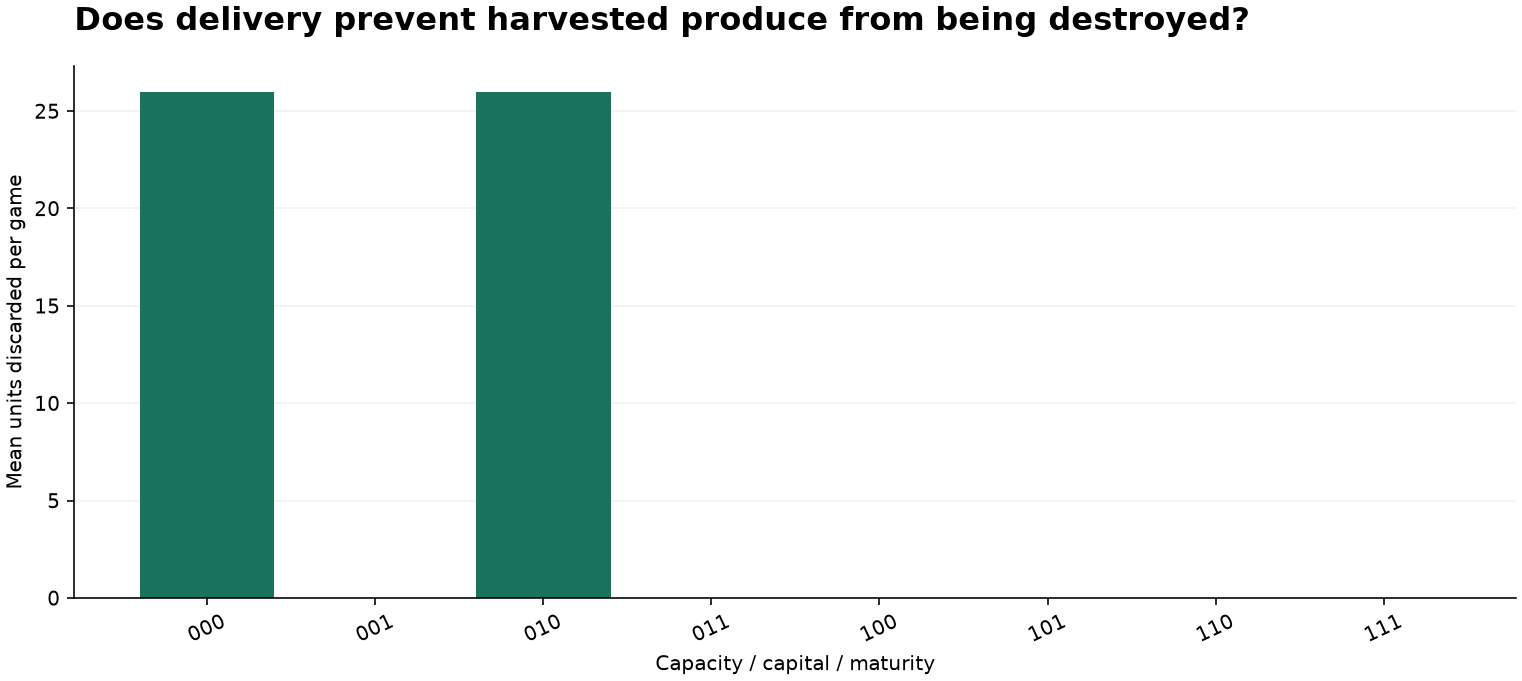

In [11]:
accounted = games2.sold_units + games2.unsold_product_units + games2.discarded_units
assert (games2.harvested_units == accounted).all()
display(
    games2.groupby("arm")[
        [
            "harvested_units",
            "sold_units",
            "discarded_units",
            "unsold_product_units",
            "ineffective_farm_actions",
            "interventions_capacity",
            "interventions_capital",
            "interventions_maturity",
        ]
    ]
    .mean()
    .round(3)
)
fig = go.Figure(go.Bar(x=groups2.index, y=groups2.mean_discarded_units, name="Discarded produce"))
fig.update_layout(
    title="Does delivery prevent harvested produce from being destroyed?",
    xaxis_title="Capacity / capital / maturity",
    yaxis_title="Mean units discarded per game",
    xaxis_type="category",
)
show_figure(fig)

### Feature coverage is not the same as feature usefulness

The bank combines 244 original current-state descriptors with 374 new relationship and
history descriptors. Every fourth callback plus the final callback is profiled; the
history object still sees every consecutive turn. Missing lags have explicit masks.
There are 181 sampled states per game. No turn-level train/test split is made.

Availability, finite values, stable schemas, empirical variation, exact duplicates and
high Spearman dependence are screened. Constant animal-care features mean **missing
policy coverage**, not evidence that livestock is useless. No candidate is rejected
or retained for a final model based merely on these descriptive checks.

In [12]:
variable2 = registry2.assign(variable=lambda d: d.distinct_development_values > 1)
coverage2 = variable2.groupby("family").agg(
    generated=("feature", "size"), variable_in_this_design=("variable", "sum")
)
coverage2["constant_coverage_gaps"] = coverage2.generated - coverage2.variable_in_this_design
display(coverage2)
display(
    pd.Series(
        {
            "Exact nonconstant duplicate groups": len(
                relationships["screening"]["exact_duplicate_groups"]
            ),
            "Pairs with absolute Spearman >= 0.995": relationships["screening"][
                "high_spearman_pairs"
            ],
            "Policy median milliseconds": relationships["policy_latency_ms"]["median"],
            "Policy p95 milliseconds": relationships["policy_latency_ms"]["p95"],
            "Full-bank median milliseconds": relationships["sampled_feature_bank_latency_ms"][
                "median"
            ],
            "Sampled full-bank p95 milliseconds": relationships["sampled_feature_bank_latency_ms"][
                "p95"
            ],
        },
        name="Diagnostics",
    )
    .to_frame()
    .round(3)
)

,generated,variable_in_this_design,constant_coverage_gaps
family,,,
animal_feed_care_interactions,42,0,42
animal_state,36,0,36
cashflow,7,5,2
causal_market_history,40,28,12
crop_resource_timing,150,94,56
crop_state,70,46,24
cross_resource_interactions,4,3,1
delivery_feasibility,32,27,5
horizon,5,5,0


,Diagnostics
Exact nonconstant duplicate groups,23.000
Pairs with absolute Spearman >= 0.995,202.000
Policy median milliseconds,4.328
Policy p95 milliseconds,5.180
Full-bank median milliseconds,2.007
Sampled full-bank p95 milliseconds,2.349


### What must happen before feature engineering can close?

The major open families are competitive price-impact scenarios and crop-mix adaptation;
joint harvest/delivery routing; fertilizer acquisition and timing; livestock feed/care,
wheat and fertilizer loops; land-expansion return on capital; and safe temporal/opponent
models. The first study's distance and staffing interventions also need separation.

The new descriptors are available for these studies, but descriptors without policy
activation and controlled ablation are **not completed research**. We still need broader
development seeds and opponents, structured stress states and evidence of diminishing
returns. Validation and holdout remain untouched. Final optimization and submission
remain blocked; this notebook is deliberately still an open research notebook.

Domain methods: the [official interpreter](https://github.com/Kaggle/kaggle-environments/tree/master/kaggle_environments/envs/kaggriculture)
defines the actual farming economy. [Finite-horizon inventory research](https://business.columbia.edu/faculty/research/optimal-dynamic-pricing-inventories-stochastic-demand-over-finite-horizons)
motivates inventory × time-to-sale interactions, not a transplant of its pricing model.
[Hooker, Mentch and Zhou](https://arxiv.org/abs/1905.03151) motivate caution with
importance methods that destroy dependence. Here we use controlled policy interventions.

## Study 3 · Post-decision markets and delivery opportunity cost

This preregistered 2×2 study uses **six fresh development seeds**, both seats and four
arms (48 games). The frozen baseline is the maturity policy `001`; the opponent is
the previous capacity-plus-maturity policy `101`. Digits mean **delivery / market timing**.
Arm `00` is exactly the frozen baseline. No validation or holdout seeds are used.

The mechanisms are not a learned price forecast: known town consumption is combined
with a visible rival-harvest stress envelope, fixed 50:50 scenario weighting and an
exhaustive integer split of current stock between selling now and a later sale.
Holding lasts at most four callbacks and stops before the nightly deposit/final sale.
Delivery is priced against foregone crop work, with local harvest/watering safeguards.

Read the [preregistered design](../docs/market_research.md) and
[cited domain and modern-method review](../docs/domain_research.md). These are feature
interventions, not final optimization, calibrated probabilities or a leaderboard score.

In [13]:
markets = json.loads((root / "reports/market_research.json").read_text())
games3 = pd.read_csv(root / "reports/market_games.csv", dtype={"arm": str})
effects3 = pd.read_csv(root / "reports/market_effects.csv")
registry3 = pd.read_csv(root / "reports/market_registry.csv")
assert len(games3) == markets["games"] == 48
assert games3.seed.nunique() == 6
assert set(games3.seed).isdisjoint(set(games2.seed))
assert not markets["validation_or_holdout_used"]
assert markets["feature_completion_gate"] == "closed"
display(
    pd.Series(
        {
            "Games": len(games3),
            "Fresh development seed clusters": games3.seed.nunique(),
            "Total candidate descriptors": len(registry3),
            "New market/delivery descriptors": 315,
            "Profiled legal states": markets["screening"]["sampled_development_observations"],
            "Features selected for final model": 0,
        },
        name="Scope",
    ).to_frame()
)

,Scope
Games,48
Fresh development seed clusters,6
Total candidate descriptors,933
New market/delivery descriptors,315
Profiled legal states,8688
Features selected for final model,0


### Does the additional structure actually help?

Win plus half a tie is the primary local outcome. Coin production, opponent-relative
margin, waste and cash diagnose mechanisms; more features or more coins do not by
themselves establish a stronger competitive agent. Each arm has 12 games but only
six independent seed clusters.

,games,match_score,coins,margin,discarded,terminal_unsold
arm,,,,,,
00,12,0.000,31984.917,-3576.083,0.0,0.0
01,12,0.000,31194.417,-5056.917,0.0,0.0
10,12,0.167,34628.417,-1032.667,0.0,0.0
11,12,0.000,33269.750,-4073.000,0.0,0.0


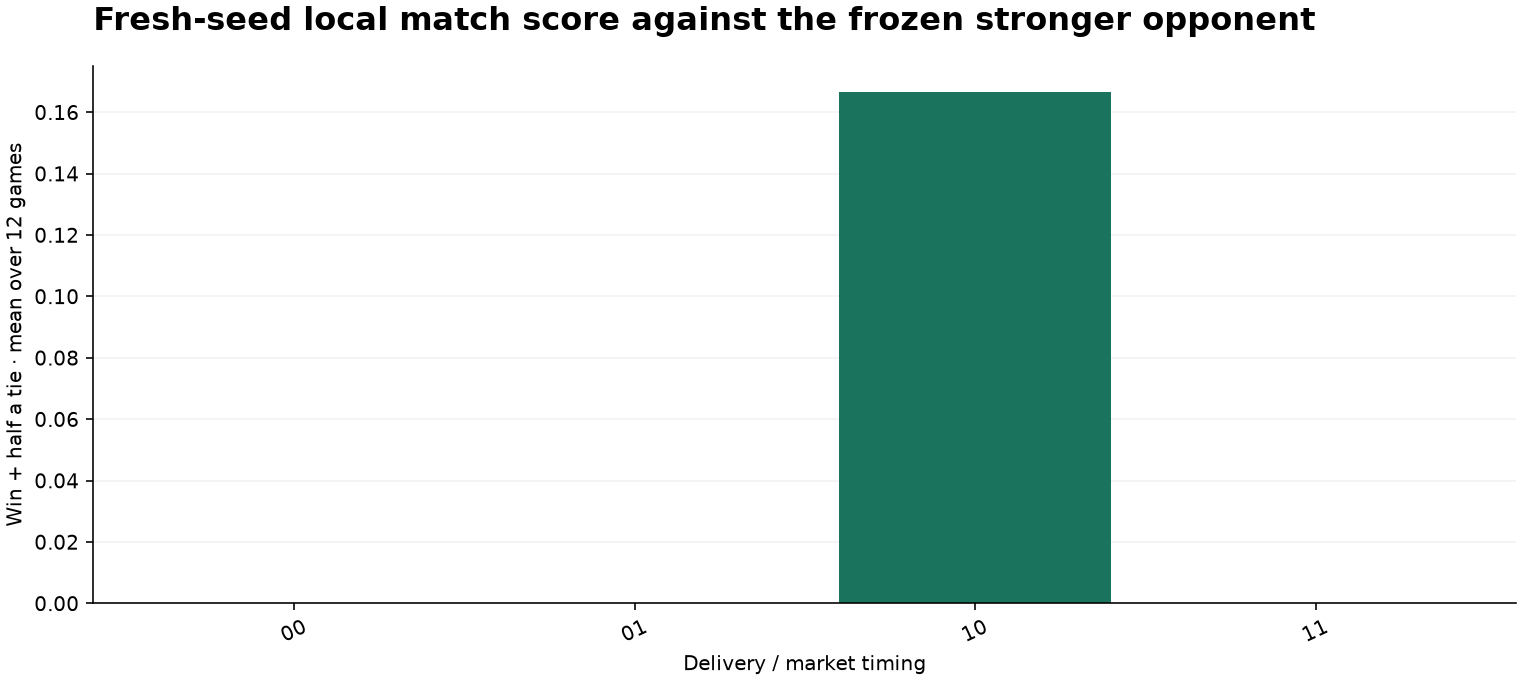

In [14]:
groups3 = games3.groupby("arm").agg(
    games=("match_score", "size"),
    match_score=("match_score", "mean"),
    coins=("coins", "mean"),
    margin=("coin_margin", "mean"),
    discarded=("discarded_units", "mean"),
    terminal_unsold=("unsold_product_units", "mean"),
)
display(groups3.round(3))
fig = go.Figure(go.Bar(x=groups3.index, y=groups3.match_score))
fig.update_layout(
    title="Fresh-seed local match score against the frozen stronger opponent",
    xaxis_title="Delivery / market timing",
    xaxis_type="category",
    yaxis_title="Win + half a tie · mean over 12 games",
    yaxis_range=[0, 1],
)
show_figure(fig)

### Paired effects and interaction

Main effects average ON-minus-OFF over the other factor. The interaction is a
difference-in-differences. Intervals resample 4,000 sets of six whole seed clusters,
keeping both seats and all four arms together. These exploratory intervals do not
correct for all historical design choices or establish generalization to the field.

In [15]:
display(
    effects3[effects3.metric.isin(["match_score", "coins", "discarded_units"])][
        ["contrast", "metric", "effect", "bootstrap_low", "bootstrap_high", "seed_clusters"]
    ].round(3)
)

,contrast,metric,effect,bootstrap_low,bootstrap_high,seed_clusters
0,delivery,match_score,0.083,0.000,0.250,6
1,delivery,coins,2359.417,1138.333,3647.458,6
3,delivery,discarded_units,0.000,0.000,0.000,6
5,market_timing,match_score,-0.083,-0.250,0.000,6
6,market_timing,coins,-1074.583,-1253.096,-740.917,6
8,market_timing,discarded_units,0.000,0.000,0.000,6
10,delivery:market_timing,match_score,-0.167,-0.500,0.000,6
11,delivery:market_timing,coins,-568.167,-904.500,64.500,6
13,delivery:market_timing,discarded_units,0.000,0.000,0.000,6


### Activation and exact product accounting

The intervention counter records changed commands, not successful causal mechanisms.
Every crop product is accounted for as sold, discarded or held at termination. Negative
results and inactive components remain visible rather than being removed after testing.

In [16]:
assert (
    games3.harvested_units
    == games3.sold_units + games3.discarded_units + games3.unsold_product_units
).all()
display(
    games3.groupby("arm")[
        [
            "interventions_delivery",
            "interventions_market_timing",
            "harvested_units",
            "sold_units",
            "discarded_units",
            "unsold_product_units",
            "ineffective_farm_actions",
            "minimum_observed_cash",
        ]
    ]
    .mean()
    .round(3)
)

,interventions_delivery,interventions_market_timing,harvested_units,sold_units,discarded_units,unsold_product_units,ineffective_farm_actions,minimum_observed_cash
arm,,,,,,,,
00,0.000,0.000,339.333,339.333,0.0,0.0,0.0,14.0
01,0.000,11.167,339.333,339.333,0.0,0.0,0.0,14.0
10,38.167,0.000,293.083,293.083,0.0,0.0,0.0,976.0
11,37.917,17.417,294.250,294.250,0.0,0.0,0.0,976.0


### Descriptive coverage, not a claim of exhaustive predictive selection

The 933-column bank adds 315 mechanistic market/delivery descriptors to the prior 618.
Counterfactual inputs use legal observations and known rules only. Supply waves assume
optimistic independent delivery and exclude hidden stocks, later growth, decay and
competition between jobs. Newly unlocked shops cannot be predicted from a game seed.

Livestock, fertilizer, land expansion, adaptive crop mix, richer routing and opponent
learning still need their own activated tests. See the coverage ledger for the explicit
remaining work. The feature-completion gate remains closed.

In [17]:
display(
    registry3.assign(variable=lambda d: d.distinct_development_values > 1)
    .groupby("family")
    .agg(generated=("feature", "size"), varying=("variable", "sum"))
)
display(
    pd.Series(
        {
            "Constant coverage gaps": len(markets["screening"]["constant_features"]),
            "Exact duplicate groups": len(markets["screening"]["exact_duplicate_groups"]),
            "Highly correlated pairs": markets["screening"]["high_spearman_pairs"],
            "Policy median ms": markets["policy_latency_ms"]["median"],
            "Policy p95 ms": markets["policy_latency_ms"]["p95"],
            "Feature-bank p95 ms": markets["sampled_feature_bank_latency_ms"]["p95"],
        },
        name="Diagnostics",
    ).to_frame()
)

,generated,varying
family,,
animal_feed_care_interactions,42,0
animal_state,36,0
cashflow,7,5
causal_market_history,40,27
conditional_market_paths,216,153
crop_resource_timing,150,86
crop_state,70,46
cross_resource_interactions,4,3
delivery_feasibility,32,27


,Diagnostics
Constant coverage gaps,361.000000
Exact duplicate groups,56.000000
Highly correlated pairs,670.000000
Policy median ms,4.782074
Policy p95 ms,5.676333
Feature-bank p95 ms,3.052814


## Study 4 · Does tighter rival-stock information help decisions?

The public market can hide sales at the one-coin floor. We combine public inventory
flows with the rival's public cash change and visible minimum spending. These are
**conservative bounds**, not calibrated forecasts or access to private opponent data.
The [research report](../docs/supply_research.md) derives the accounting constraints,
documents buy/sell ambiguity, and links the domain and methodological sources.

Four fixed arms (`bank`, `visible`, `history`, `cash`) face two frozen crop opponents
on development seeds 1301–1304 in both seats: 64 games. Production/delivery rules,
four-action holding limit, and 0.5 scenario weight are frozen. Validation and holdout
remain untouched. This is feature research, not final training or a Kaggle rating.

In [18]:
supply = json.loads((root / "reports/supply_research.json").read_text())
games4 = pd.read_csv(root / "reports/supply_games.csv")
effects4 = pd.read_csv(root / "reports/supply_effects.csv")
registry4 = pd.read_csv(root / "reports/supply_registry.csv")
bounds4 = pd.read_csv(root / "reports/supply_bound_diagnostics.csv")
actions4 = pd.read_csv(root / "reports/supply_action_identities.csv")
audit4 = json.loads((root / "reports/supply_integrity.json").read_text())
assert len(games4) == supply["games"] == 64
assert games4.seed.nunique() == 4 and set(games4.seed).isdisjoint(games3.seed)
assert not supply["validation_or_holdout_used"]
assert supply["feature_completion_gate"] == "closed"
display(
    pd.Series(
        {
            "Games": 64,
            "Fresh seed clusters": 4,
            "Frozen opponents": 2,
            "Joint provisional features": len(registry4),
            "New cash features": 42,
            "Features selected for final model": 0,
        },
        name="Scope",
    ).to_frame()
)

,Scope
Games,64
Fresh seed clusters,4
Frozen opponents,2
Joint provisional features,1308
New cash features,42
Features selected for final model,0


### Primary outcome: wins and ties, not coin production alone

Each opponent/arm group has eight games but only four independent seed clusters.
The full 0–1 vertical scale is preserved in both interactive and static figures.
Opponent families share crop-policy ancestry; this is not a population-wide ranking.
History/cash scored 0.625 pooled versus bank's 0.375. The gain consists entirely of
eight mirror-match ties becoming narrow wins; score against relationship101 did
not improve. This does not justify a general competitive-performance claim.

games  wins  ties  score     coins   margin
opponent        arm                                                 
market10        bank         8     0     8   0.50  34796.25     0.00
                cash         8     8     0   1.00  34845.50    92.75
                history      8     8     0   1.00  34845.50    92.75
                visible      8     0     0   0.00  33228.00 -3179.75
relationship101 bank         8     2     0   0.25  33661.75 -1043.00
                cash         8     2     0   0.25  33691.75  -978.00
                history      8     2     0   0.25  33691.75  -978.00
                visible      8     0     0   0.00  32077.50 -4252.75

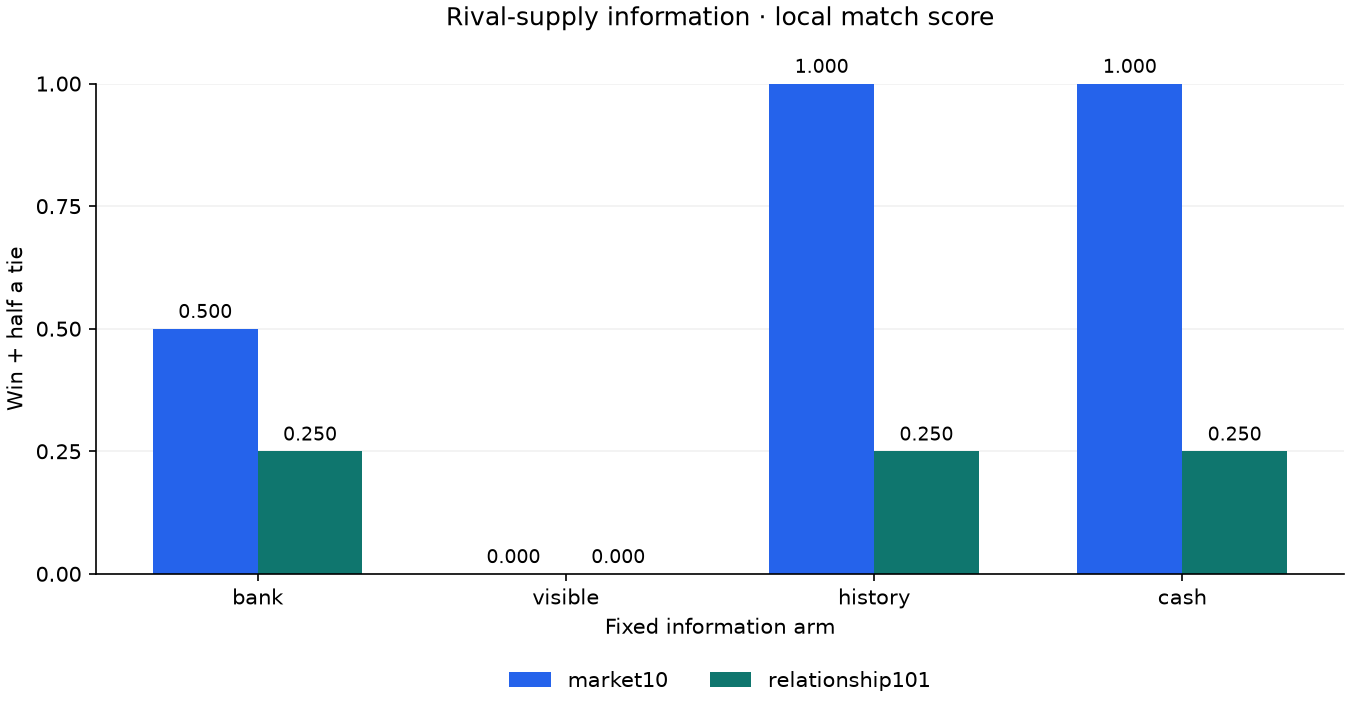

In [19]:
import sys

sys.path.insert(0, str(root / "scripts"))
from supply_plots import show_match_scores

groups4 = games4.groupby(["opponent", "arm"]).agg(
    games=("match_score", "size"),
    wins=("match_score", lambda s: (s == 1).sum()),
    ties=("match_score", lambda s: (s == 0.5).sum()),
    score=("match_score", "mean"),
    coins=("coins", "mean"),
    margin=("coin_margin", "mean"),
)
display(groups4.round(3))
score_table4 = groups4.score.unstack("opponent").reindex(["bank", "visible", "history", "cash"])
show_match_scores(score_table4)

### Registered paired contrasts

Visible−bank tests the existing holding rule. History−visible tests stored-supply
information. Cash−history tests tighter cash constraints. Cash−bank tests the overall
practical change. Bootstrap intervals resample four **whole seed clusters**, retaining
seats and opponents together. They are descriptive, not confirmatory significance tests.
All seed differences remain available in the linked outcome files. Every cash-bank
seed mean had the same +0.25 score contrast, so its bootstrap interval collapses;
that does not establish zero population uncertainty. Cash/history produced identical
complete action sequences in all 16 matched games: no incremental decision gain.

In [20]:
display(
    effects4[
        (effects4.opponent == "pooled")
        & effects4.metric.isin(["match_score", "coins", "coin_margin"])
    ][["contrast", "metric", "effect", "bootstrap_low", "bootstrap_high", "seed_clusters"]].round(3)
)
display(
    games4.groupby(["opponent", "arm"])[
        [
            "interventions_market_timing",
            "supply_activations",
            "cash_extra_sale_units",
            "harvested_units",
            "sold_units",
            "discarded_units",
            "unsold_product_units",
        ]
    ]
    .mean()
    .round(3)
)
action_identity4 = actions4.pivot(
    index=["seed", "seat", "opponent"], columns="arm", values="candidate_actions_sha256"
)
display(
    pd.DataFrame(
        [
            {
                "contrast": treatment + "-" + control,
                "identical_full_action_sequences": int(
                    (action_identity4[treatment] == action_identity4[control]).sum()
                ),
                "paired_games": len(action_identity4),
            }
            for treatment, control in [
                ("visible", "bank"),
                ("history", "visible"),
                ("cash", "history"),
                ("cash", "bank"),
            ]
        ]
    )
)

,contrast,metric,effect,bootstrap_low,bootstrap_high,seed_clusters
0,visible-bank,match_score,-0.375,-0.625,-0.250,4
1,visible-bank,coins,-1576.250,-1619.750,-1520.875,4
2,visible-bank,coin_margin,-3194.750,-3291.500,-3060.750,4
5,history-visible,match_score,0.625,0.500,0.875,4
6,history-visible,coins,1615.875,1547.250,1693.375,4
7,history-visible,coin_margin,3273.625,3136.375,3415.250,4
10,cash-history,match_score,0.000,0.000,0.000,4
11,cash-history,coins,0.000,0.000,0.000,4
12,cash-history,coin_margin,0.000,0.000,0.000,4
15,cash-bank,match_score,0.250,0.250,0.250,4


interventions_market_timing  supply_activations  \
opponent        arm                                                        
market10        bank                            0.00                0.00   
                cash                            8.25               22.75   
                history                         8.25               22.75   
                visible                        21.25                0.00   
relationship101 bank                            0.00                0.00   
                cash                            8.25               21.25   
                history                         8.25               21.25   
                visible                        17.75                0.00   

                         cash_extra_sale_units  harvested_units  sold_units  \
opponent        arm                                                           
market10        bank                     34.00           293.25      293.25   
                cash                     34.50           293.25      293.25   
                history                  34.50           293.25      293.25   
                visible                  30.50           293.25      293.25   
relationship101 bank                     12.50           287.00      287.00   
                cash                     13.50           287.00      287.00   
                history                  13.50           287.00      287.00   
                visible                   6.75           287.00      287.00   

                         discarded_units  unsold_product_units  
opponent        arm                                             
market10        bank                 0.0                   0.0  
                cash                 0.0                   0.0  
                history              0.0                   0.0  
                visible              0.0                   0.0  
relationship101 bank                 0.0                   0.0  
                cash                 0.0                   0.0  
                history              0.0                   0.0  
                visible              0.0                   0.0

,contrast,identical_full_action_sequences,paired_games
0,visible-bank,0,16
1,history-visible,0,16
2,cash-history,16,16
3,cash-bank,0,16


### Identification quality is distinct from decision quality

Only the post-run auditor reads rival private inventory. A useful bound must contain
the truth, but excessive width or persistent false alarms can still make it a poor
forecast. Report both containment and conservatism; do not call every tighter bound
a predictive win. Cash constraints reduced accumulated excess melon-stock bounds
by 13.19%, but empty-stock warnings did not decrease. Zero livestock stock here is
a coverage gap, not a rejection.

In [21]:
display(
    bounds4.groupby("product")[
        [
            "callbacks",
            "actual_stock_positive",
            "strictly_tighter",
            "loose_excess",
            "cash_excess",
            "loose_false_positive",
            "cash_false_positive",
            "sale_units",
            "loose_sale_lower",
            "cash_sale_lower",
        ]
    ].sum()
)
assert audit4["bound_violations"] == 0
assert audit4["policy_action_mismatches"] == 0
assert (bounds4.cash_excess <= bounds4.loose_excess).all()

,callbacks,actual_stock_positive,strictly_tighter,loose_excess,cash_excess,loose_false_positive,cash_false_positive,sale_units,loose_sale_lower,cash_sale_lower
product,,,,,,,,,,
CARROT,46016,3616,0,0,0,0,0,1304,1304,1304
EGG,46016,0,0,0,0,0,0,0,0,0
MELON,46016,3712,24550,2328376,2021154,26112,26112,11712,5142,6580
MILK,46016,0,0,0,0,0,0,0,0,0
STRAWBERRY,46016,2664,0,147472,147472,7832,7832,4512,4512,4512
TOMATO,46016,0,0,0,0,0,0,0,0,0
WOOL,46016,0,0,0,0,0,0,0,0,0


### Joint feature screening, without premature selection

All 1,308 columns are screened together: 933 earlier descriptors, 333 history
descriptors and 42 cash descriptors. Constants and duplicates are coverage/redundancy
flags. They are not automatically rejected or represented as validated predictors.

In [22]:
display(
    registry4.assign(varying=lambda d: d.distinct_development_values > 1)
    .groupby("family")
    .agg(generated=("feature", "size"), varying=("varying", "sum"))
)
display(
    pd.Series(
        {
            "Constant columns": len(supply["screening"]["constant_features"]),
            "Exact duplicate groups": len(supply["screening"]["exact_duplicate_groups"]),
            "High-correlation pairs": supply["screening"]["high_spearman_pairs"],
            "Sampled legal observations": supply["screening"]["sampled_development_observations"],
            "Policy p95 milliseconds": supply["policy_latency_ms"]["p95"],
        },
        name="Screen",
    ).to_frame()
)

,generated,varying
family,,
animal_feed_care_interactions,42,0
animal_state,36,0
buyable_cash_ambiguity,4,3
cash_constrained_supply,35,13
cashflow,7,5
causal_market_history,40,28
causal_supply_bounds,99,37
conditional_market_paths,216,153
crop_resource_timing,150,82


,Screen
Constant columns,554.000000
Exact duplicate groups,74.000000
High-correlation pairs,1866.000000
Sampled legal observations,11584.000000
Policy p95 milliseconds,6.664813


### Restartable evidence and an open research gate

Completed episodes are checksummed and uploaded to private versioned S3. Source,
engine and protocol hashes must match before reuse. The policy is serialized and
restored 31 times in every game. The independent replay recomputes all sampled
features, checks every candidate action and verifies product conservation.

See the [coverage ledger](../docs/feature_coverage.md) for remaining livestock/feed,
fertilizer, land, crop-mix, routing and opponent-belief research. No final model is
trained or promoted here. No top-score guarantee follows from this experiment.

In [23]:
assert audit4["games_verified"] == 64
assert audit4["candidate_callbacks_verified"] == 64 * 719
assert audit4["sampled_feature_vectors_recomputed"] == 64 * 181
assert (
    games4.harvested_units
    == games4.sold_units + games4.discarded_units + games4.unsold_product_units
).all()
display(
    pd.Series(
        {
            key: audit4[key]
            for key in [
                "games_verified",
                "candidate_callbacks_verified",
                "sampled_feature_vectors_recomputed",
                "stock_containment_checks",
                "sale_containment_checks",
                "bound_violations",
                "policy_action_mismatches",
                "state_roundtrips",
                "feature_completion_gate",
            ]
        },
        name="Verified evidence",
    ).to_frame()
)

,Verified evidence
games_verified,64
candidate_callbacks_verified,46016
sampled_feature_vectors_recomputed,11584
stock_containment_checks,322112
sale_containment_checks,321664
bound_violations,0
policy_action_mismatches,0
state_roundtrips,1984
feature_completion_gate,closed
